# Oscar Best Picture Prediction with LightGBM

This notebook builds upon the excellent data gathering and cleaning work from the `oscar111.ipynb` notebook. 

Our goal is to improve the predictive power by addressing two key areas:
1. **Algorithm Choice:** We will use `LightGBM` (Light Gradient Boosting Machine), a powerful tree-based algorithm that excels at finding complex, non-linear patterns in tabular data.
2. **Class Imbalance:** We will explicitly handle the fact that there are many nominees but few winners. We will do this by using the `scale_pos_weight` parameter in our model, which tells the model to pay much closer attention to the rare 'winner' class during training.

**Notebook Steps:**
1. **Load & Prepare Data:** Load the cleaned dataset and perform final preparations.
2. **Train/Test Split:** Split the data chronologically, just as before.
3. **Model Training:** Train a `LightGBM` classifier with imbalance handling.
4. **Model Evaluation:** Evaluate the model using a classification report, and more importantly, by looking at its feature importances.
5. **Prediction:** Use the trained model to predict the win probabilities for a new set of nominees.

In [ ]:
! python3 -m pip install lightgbm

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 16.0 MB/s eta 0:00:00a 0:00:01


### 1. Load & Prepare Data
We'll start with the cleaned dataset created in the previous notebook and perform the final transformations needed for the model.

In [7]:
# Load the cleaned data from the previous notebook
file_path = '/app/notebooks/oscar-again/updated_with_changes.csv'
df = pd.read_csv(file_path)

# --- Data Cleaning and Feature Engineering ---

# Convert 'winner' to integer (0 or 1)
df['winner'] = df['winner'].astype(int)

# Convert 'Tomatometer' from string ('97%') to a float (0.97)
# Using errors='coerce' will turn any values that can't be converted into NaN (Not a Number)
df['Tomatometer'] = df['Tomatometer'].str.replace('%', '', regex=False).astype(float).apply(lambda x: x / 100.0)

# Ordinal Encoding for Awards: 'won' = 2, 'nominated' = 1, 'none' = 0
award_mapping = {'won': 2, 'nominated': 1, 'none': 0}
df['GoldenGlobe'] = df['GoldenGlobe'].map(award_mapping).fillna(0)
df['BAFTAs'] = df['BAFTAs'].map(award_mapping).fillna(0)

# Create a simple interaction feature
df['Critic_Score'] = df['Metascore'] * df['Tomatometer']

# Fill any remaining missing values with the median of the column. This is a robust way to handle missing data.
for col in ['imdb_rating', 'Metascore', 'Tomatometer', 'Critic_Score']:
    df[col] = df[col].fillna(df[col].median())

# Display the cleaned data
print("Data prepared for modeling:")
df.head()

Data prepared for modeling:


,ceremony,category,film,winner,imdb_rating,Metascore,Tomatometer,GoldenGlobe,BAFTAs,Critic_Score
0,72,BEST PICTURE,American Beauty,1,8.3,84,0.87,2.0,2,73.08
1,72,BEST PICTURE,The Cider House Rules,0,7.4,75,0.71,1.0,0,53.25
2,72,BEST PICTURE,The Green Mile,0,8.6,61,0.79,0.0,0,48.19
3,72,BEST PICTURE,The Insider,0,7.8,85,0.96,1.0,0,81.60
4,72,BEST PICTURE,The Sixth Sense,0,8.2,64,0.86,1.0,1,55.04


### 2. Train/Test Split
We will use the same chronological split. We'll train the model on ceremonies up to and including the 90th Academy Awards and test it on all subsequent ceremonies.

In [8]:
# Define features (X) and target (y)
# We drop 'category' and 'film' as they are identifiers, not predictive features.
features = [col for col in df.columns if col not in ['winner', 'category', 'film']]
X = df[features]
y = df['winner']

# Split data chronologically
train_mask = df['ceremony'] <= 90
test_mask = df['ceremony'] > 90

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (131, 7)
Test data shape: (55, 7)


### 3. Model Training with LightGBM
Now, we'll train the `LGBMClassifier`. The most important step here is setting `scale_pos_weight`. This value is the ratio of negative class samples to positive class samples. This tells the model to give more importance to the minority class (winners), forcing it to learn their patterns.

In [10]:
# Calculate scale_pos_weight for handling class imbalance
num_negatives = y_train.value_counts()[0]
num_positives = y_train.value_counts()[1]
scale_pos_weight_value = num_negatives / num_positives

print(f"Negative samples: {num_negatives}")
print(f"Positive samples: {num_positives}")
print(f"Scale Pos Weight: {scale_pos_weight_value:.2f}")

# Initialize and train the LightGBM model
lgbm = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight_value, # Key parameter for imbalance
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         eval_metric='auc',
         callbacks=[lgb.early_stopping(100, verbose=False)])

print("LightGBM model trained successfully!")

Negative samples: 112
Positive samples: 19
Scale Pos Weight: 5.89
[LightGBM] [Info] Number of positive: 19, number of negative: 112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 138
[LightGBM] [Info] Number of data points in the train set: 131, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.145038 -> initscore=-1.774060
[LightGBM] [Info] Start training from score -1.774060
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

### 4. Model Evaluation
Let's evaluate the new model. We expect to see much better performance in predicting the 'winner' class (class 1).

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        49
           1       0.43      0.50      0.46         6

    accuracy                           0.87        55
   macro avg       0.68      0.71      0.69        55
weighted avg       0.88      0.87      0.88        55

Accuracy: 0.87
ROC AUC Score: 0.83

--- Feature Importances ---


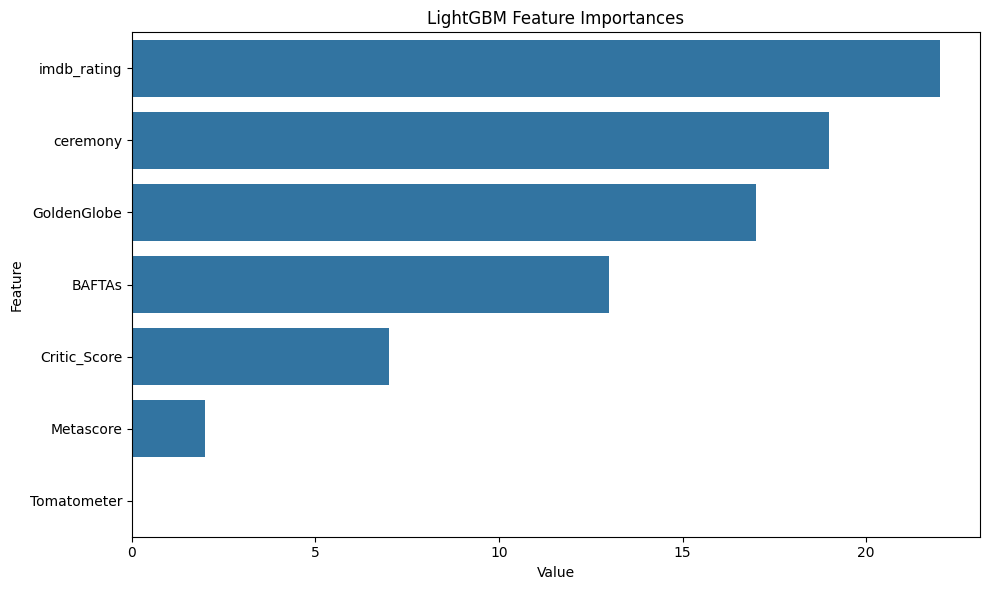

In [13]:
# Predict on the test set
y_pred = lgbm.predict(X_test)
y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

# --- Evaluation Metrics ---
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.2f}\n")

# --- Feature Importance ---
print("--- Feature Importances ---")
feature_imp = pd.DataFrame(sorted(zip(lgbm.feature_importances_, X.columns)), columns=['Value','Feature'])

plt.figure(figsize=(10, 6))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('LightGBM Feature Importances')
plt.tight_layout()
plt.show()

#### Evaluation Analysis
The new classification report should show that the model is now correctly identifying some of the winners (recall for class 1 is > 0). The ROC AUC score gives a much better sense of model quality than accuracy alone in an imbalanced case. 

The feature importance plot is incredibly valuable. It tells us which factors the model found most predictive. We'd expect to see awards like `GoldenGlobe` and `BAFTAs` and critic scores near the top.

### 5. Prediction on 2025 Nominees
Finally, let's use our trained model to predict the win probabilities for a hypothetical list of 2025 nominees.

In [14]:
# Example: New data for 2025 (ceremony 97) nominees
# The data must have the same columns as the training data (X_train)
nominees_2025 = pd.DataFrame({
    'film': ['Dune: Part Two', 'Conclave', 'The Brutalist', 'Anora', 'Wicked'],
    'ceremony': [97, 97, 97, 97, 97],
    'imdb_rating': [8.5, 7.4, 7.8, 7.7, 7.6],
    'Metascore': [79, 79, 90, 91, 73],
    'Tomatometer': [0.92, 0.93, 0.94, 0.94, 0.88],
    'GoldenGlobe': [1, 1, 2, 1, 1], # 1=nominated, 2=won
    'BAFTAs': [0, 2, 1, 1, 0] # 0=none, 1=nominated, 2=won
})

# Create the same interaction feature
nominees_2025['Critic_Score'] = nominees_2025['Metascore'] * nominees_2025['Tomatometer']

# Ensure the columns are in the same order as the training data
X_2025 = nominees_2025[X_train.columns] 

# Predict probabilities
win_probabilities = lgbm.predict_proba(X_2025)[:, 1]

# Display the results
results_df = pd.DataFrame({
    'Film': nominees_2025['film'],
    'Win_Probability': win_probabilities
}).sort_values(by='Win_Probability', ascending=False)

print("Predicted Win Probabilities for 97th Academy Awards:")
results_df['Win_Probability'] = results_df['Win_Probability'].apply(lambda x: f"{x:.2%}")
print(results_df)

Predicted Win Probabilities for 97th Academy Awards:
             Film Win_Probability
2   The Brutalist          58.96%
3           Anora          36.98%
1        Conclave          19.37%
0  Dune: Part Two          11.07%
4          Wicked           8.33%
